# TP3 — Text Mining : Étude comparative de méthodes de classification de textes
**Dataset :** eCommerce Product Classification (Zenodo — DOI: 10.5281/zenodo.3355823)  
**Algorithmes :** Decision Tree | KNN | SVM | XGBoost  
**Sélection de variables :** Chi-Square | Mutual Information | Information Gain | Fisher's Score

## Bloc 1 — Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import copy
import warnings
warnings.filterwarnings('ignore')
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/malakmekyassi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Bloc 2 — Chargement et exploration du dataset

In [3]:
df = pd.read_csv('data/data.csv', header=None, names=['label', 'text'])
print(f'Shape : {df.shape}')
df.head()

Shape : (50425, 2)


,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   50425 non-null  object
 1   text    50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


In [5]:
print('Distribution des classes :')
print(df['label'].value_counts())
print(f'\nValeurs manquantes : {df.isnull().sum().sum()}')

Distribution des classes :
label
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64

Valeurs manquantes : 1


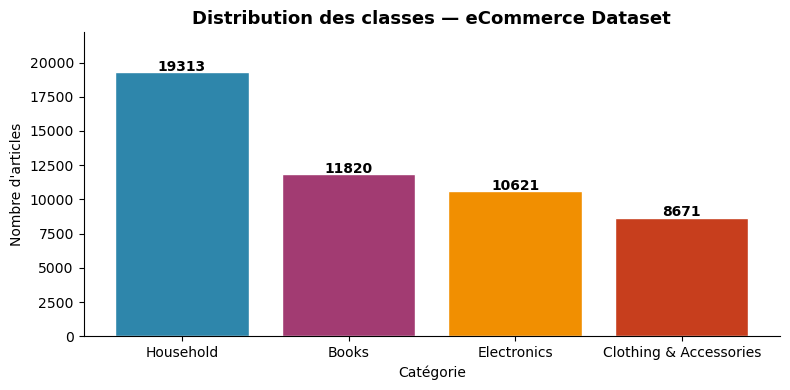

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['label'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribution des classes — eCommerce Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel("Nombre d'articles")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Bloc 3 — Prétraitement du texte

Pipeline appliqué :
1. Mise en minuscules
2. Suppression des URLs, mentions et caractères spéciaux
3. Suppression des stop-words (NLTK)
4. Stemming léger par règles de suffixes

In [7]:
import re
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOP_WORDS and len(word) > 1]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

In [8]:
df.dropna(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)

df['text_clean'] = df['text'].apply(preprocess_text)

avg_before = df['text'].apply(lambda x: len(str(x).split())).mean()
avg_after  = df['text_clean'].apply(lambda x: len(x.split())).mean()
print(f'Longueur moyenne avant prétraitement : {avg_before:.1f} tokens')
print(f'Longueur moyenne après prétraitement : {avg_after:.1f} tokens')
print(f'Réduction : {(1 - avg_after/avg_before)*100:.1f}%')
print(f'\nExemple :')
print(f'  AVANT : {df["text"].iloc[0][:120]}')
print(f'  APRÈS : {df["text_clean"].iloc[0][:120]}')

Longueur moyenne avant prétraitement : 114.2 tokens
Longueur moyenne après prétraitement : 74.1 tokens
Réduction : 35.1%

Exemple :
  AVANT : Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up
  APRÈS : paper plane design frame wall hang motiv offic decor art print 87 87 inch set paint made synthet frame uv textur print g


In [9]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print('Classes encodées :', dict(zip(le.classes_, le.transform(le.classes_))))

Classes encodées : {'Books': 0, 'Clothing & Accessories': 1, 'Electronics': 2, 'Household': 3}


## Bloc 4 — Vectorisation TF-IDF et Split Train/Test

**TF-IDF** pondère chaque terme par sa fréquence dans le document relativement à sa fréquence dans le corpus :

$$\text{TF-IDF}(t,d) = TF(t,d) \times \log\left(\frac{N}{df(t)}\right)$$

Paramètres : `max_features=5000`, `ngram_range=(1,2)`, `min_df=2`, `sublinear_tf=True`

In [10]:
X = df['text_clean'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
feature_names = np.array(tfidf.get_feature_names_out())

print(f'Train : {X_train_tfidf.shape}')
print(f'Test  : {X_test_tfidf.shape}')
print(f'Vocabulaire : {len(feature_names)} termes')

Train : (40339, 5000)
Test  : (10085, 5000)
Vocabulaire : 5000 termes


## Bloc 5 — Sélection de variables (Feature Selection)

Quatre méthodes sont appliquées pour réduire l'espace de 5000 à **1000 features** :

| Méthode | Principe |
|---|---|
| **Chi-Square** | Mesure la dépendance statistique entre le terme et la classe. |
| **Mutual Information** | Calcule la dépendance entre les valeurs continues (TF-IDF) et la classe. |
| **Information Gain** | Mesure la réduction d'entropie basée sur la présence/absence binaire du terme. |
| **Fisher's Score** | Évalue le pouvoir discriminant en calculant le ratio des variances (ANOVA F-test). |

In [11]:
def fisher_score(X, y):

    X_dense = X.toarray() if hasattr(X, 'toarray') else X
    overall_mean = X_dense.mean(axis=0)
    numerator    = np.zeros(X_dense.shape[1])
    denominator  = np.zeros(X_dense.shape[1])
    for c in np.unique(y):
        mask = (y == c)
        Xc   = X_dense[mask]
        nc   = mask.sum()
        numerator   += nc * (Xc.mean(axis=0) - overall_mean) ** 2
        denominator += nc * Xc.var(axis=0)
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return numerator / denominator


K_FEATURES = 1000
METHODS = ['chi2', 'mutual_info', 'info_gain', 'fisher']
METHOD_LABELS = {
    'chi2':        'Chi-Square',
    'mutual_info': 'Mutual Information',
    'info_gain':   'Information Gain',
    'fisher':      "Fisher's Score"
}

fs_results = {}

for method in METHODS:
    if method == 'chi2':
        sel = SelectKBest(chi2, k=K_FEATURES)
        Xtr = sel.fit_transform(X_train_tfidf, y_train)
        Xte = sel.transform(X_test_tfidf)
        sc  = sel.scores_
        idx = sel.get_support(indices=True)

    elif method == 'mutual_info':
        sel = SelectKBest(
            lambda X, y: mutual_info_classif(X, y, discrete_features=True, random_state=42),
            k=K_FEATURES
        )
        Xtr = sel.fit_transform(X_train_tfidf, y_train)
        Xte = sel.transform(X_test_tfidf)
        sc  = sel.scores_
        idx = sel.get_support(indices=True)

    elif method == 'info_gain':
        X_train_bin = (X_train_tfidf > 0).astype(int)
        sel = SelectKBest(
            lambda X, y: mutual_info_classif(X, y, discrete_features=True, random_state=42),
            k=K_FEATURES
        )
        Xtr = sel.fit_transform(X_train_bin, y_train)
        Xtr = X_train_tfidf[:, sel.get_support()]
        Xte = X_test_tfidf[:, sel.get_support()]
        sc  = sel.scores_
        idx = sel.get_support(indices=True)

    elif method == 'fisher':
        sel = SelectKBest(f_classif, k=K_FEATURES)
        Xtr = sel.fit_transform(X_train_tfidf, y_train)
        Xte = sel.transform(X_test_tfidf)
        sc  = sel.scores_
        idx = sel.get_support(indices=True)

    fs_results[method] = {'X_train': Xtr, 'X_test': Xte, 'scores': sc, 'top_idx': idx}
    print(f"[{METHOD_LABELS[method]:25s}] {Xtr.shape[1]} features — "
          f"Top-5 : {', '.join(feature_names[idx[:5]])}")

[Chi-Square               ] 1000 features — Top-5 : 100, 100 cotton, 1080p, 128gb, 156
[Mutual Information       ] 1000 features — Top-5 : 10, 100, 100 cotton, 11, 12
[Information Gain         ] 1000 features — Top-5 : 10, 100, 100 cotton, 1080p, 15 year
[Fisher's Score           ] 1000 features — Top-5 : 100, 100 cotton, 1080p, 15 year, 16gb


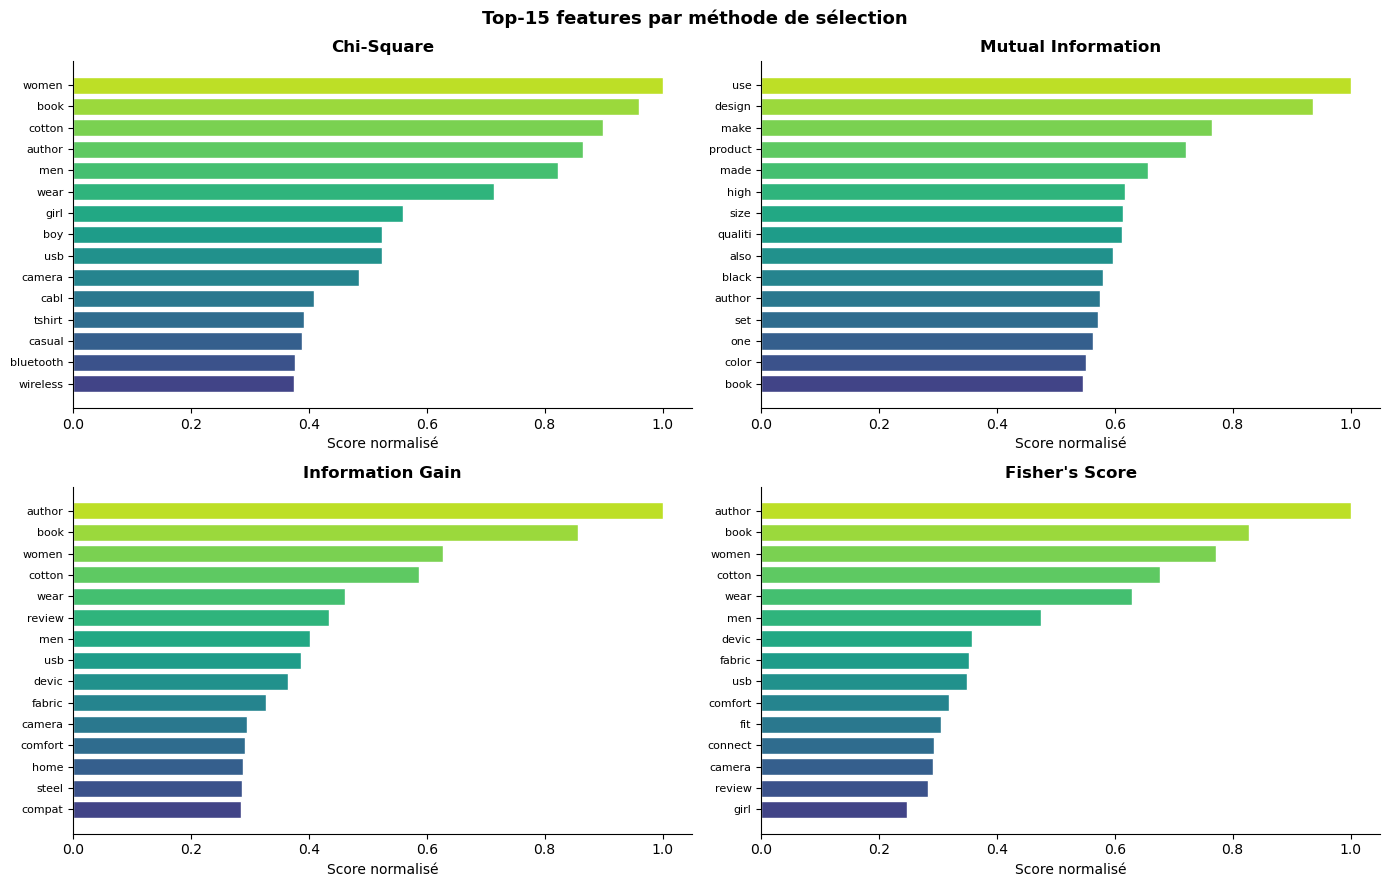

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, method in zip(axes, METHODS):
    sc  = fs_results[method]['scores']
    idx = np.argsort(sc)[::-1][:15]
    tf  = feature_names[idx]
    ts  = sc[idx] / sc[idx].max()
    colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, 15))
    ax.barh(range(15), ts[::-1], color=colors_bar, edgecolor='white')
    ax.set_yticks(range(15))
    ax.set_yticklabels(tf[::-1], fontsize=8)
    ax.set_title(METHOD_LABELS[method], fontweight='bold')
    ax.set_xlabel('Score normalisé')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Top-15 features par méthode de sélection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloc 6 — Classification

| Classifieur | Hyperparamètres clés |
|---|---|
| **Decision Tree** | `max_depth=20`, `criterion='gini'`, `min_samples_split=5` |
| **KNN** | `k=7`, `metric='cosine'`, `algorithm='brute'` |
| **SVM** | `C=1.0`, `LinearSVC`, `max_iter=3000` |
| **XGBoost** | `n_estimators=200`, `max_depth=6`, `learning_rate=0.1` |

In [13]:
def get_classifiers():
    clfs = {
        'Decision Tree': DecisionTreeClassifier(
            max_depth=20, min_samples_split=5, criterion='gini', random_state=42
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=7, metric='cosine', algorithm='brute'
        ),
        'SVM': LinearSVC(
            C=1.0, max_iter=3000, random_state=42
        ),
    }
    clfs['XGBoost'] = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=42, n_jobs=-1
        )
    return clfs


all_results = []
predictions  = {}
classifiers  = get_classifiers()

for method in METHODS:
    Xtr = fs_results[method]['X_train']
    Xte = fs_results[method]['X_test']
    for cname, clf_template in classifiers.items():
        clf = copy.deepcopy(clf_template)
        clf.fit(Xtr, y_train)
        yp  = clf.predict(Xte)
        predictions[(cname, method)] = yp
        res = {
            'Classifier': cname,
            'Method':     METHOD_LABELS[method],
            'Accuracy':   round(accuracy_score(y_test, yp), 4),
            'Precision':  round(precision_score(y_test, yp, average='weighted', zero_division=0), 4),
            'Recall':     round(recall_score(y_test, yp, average='weighted', zero_division=0), 4),
            'F1-score':   round(f1_score(y_test, yp, average='weighted', zero_division=0), 4),
        }
        all_results.append(res)
        print(f"[{METHOD_LABELS[method]:25s}] {cname:15s} → "
              f"Acc={res['Accuracy']:.4f} | P={res['Precision']:.4f} | "
              f"R={res['Recall']:.4f} | F1={res['F1-score']:.4f}")

[Chi-Square               ] Decision Tree   → Acc=0.8290 | P=0.8473 | R=0.8290 | F1=0.8314
[Chi-Square               ] KNN             → Acc=0.9439 | P=0.9439 | R=0.9439 | F1=0.9438
[Chi-Square               ] SVM             → Acc=0.9444 | P=0.9447 | R=0.9444 | F1=0.9443
[Chi-Square               ] XGBoost         → Acc=0.9421 | P=0.9426 | R=0.9421 | F1=0.9421
[Mutual Information       ] Decision Tree   → Acc=0.8297 | P=0.8480 | R=0.8297 | F1=0.8320
[Mutual Information       ] KNN             → Acc=0.9318 | P=0.9322 | R=0.9318 | F1=0.9318
[Mutual Information       ] SVM             → Acc=0.9386 | P=0.9389 | R=0.9386 | F1=0.9385
[Mutual Information       ] XGBoost         → Acc=0.9417 | P=0.9421 | R=0.9417 | F1=0.9417
[Information Gain         ] Decision Tree   → Acc=0.8289 | P=0.8474 | R=0.8289 | F1=0.8313
[Information Gain         ] KNN             → Acc=0.9437 | P=0.9437 | R=0.9437 | F1=0.9437
[Information Gain         ] SVM             → Acc=0.9418 | P=0.9420 | R=0.9418 | F1=0.9417

## Bloc 7 — Analyse et visualisation des résultats

In [14]:
results_df = pd.DataFrame(all_results)
print('Tableau récapitulatif des performances :')
results_df

Tableau récapitulatif des performances :


,Classifier,Method,Accuracy,Precision,Recall,F1-score
0,Decision Tree,Chi-Square,0.8290,0.8473,0.8290,0.8314
1,KNN,Chi-Square,0.9439,0.9439,0.9439,0.9438
2,SVM,Chi-Square,0.9444,0.9447,0.9444,0.9443
3,XGBoost,Chi-Square,0.9421,0.9426,0.9421,0.9421
4,Decision Tree,Mutual Information,0.8297,0.8480,0.8297,0.8320
5,KNN,Mutual Information,0.9318,0.9322,0.9318,0.9318
6,SVM,Mutual Information,0.9386,0.9389,0.9386,0.9385
7,XGBoost,Mutual Information,0.9417,0.9421,0.9417,0.9417
8,Decision Tree,Information Gain,0.8289,0.8474,0.8289,0.8313
9,KNN,Information Gain,0.9437,0.9437,0.9437,0.9437


In [15]:
best = results_df.loc[results_df['F1-score'].idxmax()]
print('Meilleure combinaison :')
print(f"  Classifieur : {best['Classifier']}")
print(f"  Méthode FS  : {best['Method']}")
print(f"  Accuracy    : {best['Accuracy']:.4f}")
print(f"  F1-score    : {best['F1-score']:.4f}")

Meilleure combinaison :
  Classifieur : SVM
  Méthode FS  : Chi-Square
  Accuracy    : 0.9444
  F1-score    : 0.9443


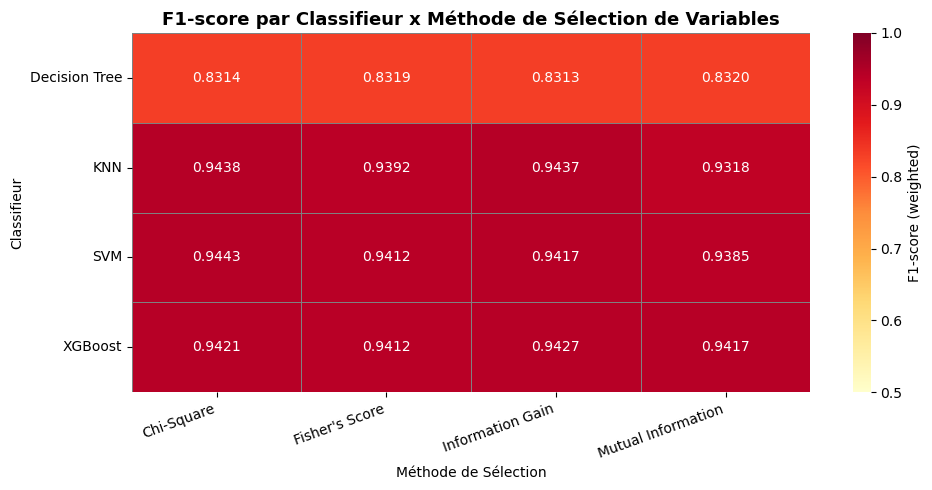

In [16]:
pivot_f1 = results_df.pivot(index='Classifier', columns='Method', values='F1-score')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray',
            vmin=0.5, vmax=1.0, ax=ax,
            cbar_kws={'label': 'F1-score (weighted)'})
ax.set_title('F1-score par Classifieur x Méthode de Sélection de Variables',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Méthode de Sélection')
ax.set_ylabel('Classifieur')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

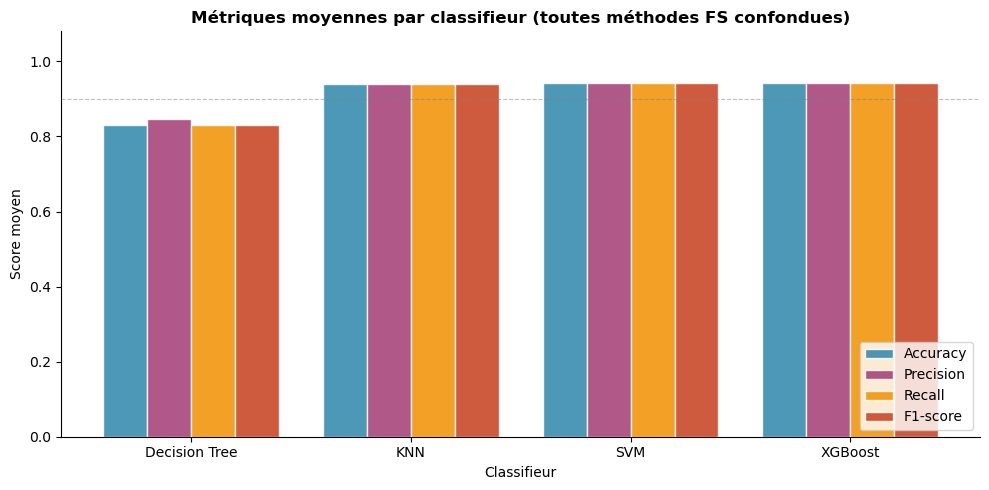

In [17]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-score']
avg_by_clf = results_df.groupby('Classifier')[metrics].mean()
colors     = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

x     = np.arange(len(avg_by_clf))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, avg_by_clf[metric], width,
           label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_title('Métriques moyennes par classifieur (toutes méthodes FS confondues)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Classifieur')
ax.set_ylabel('Score moyen')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(avg_by_clf.index)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.08)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

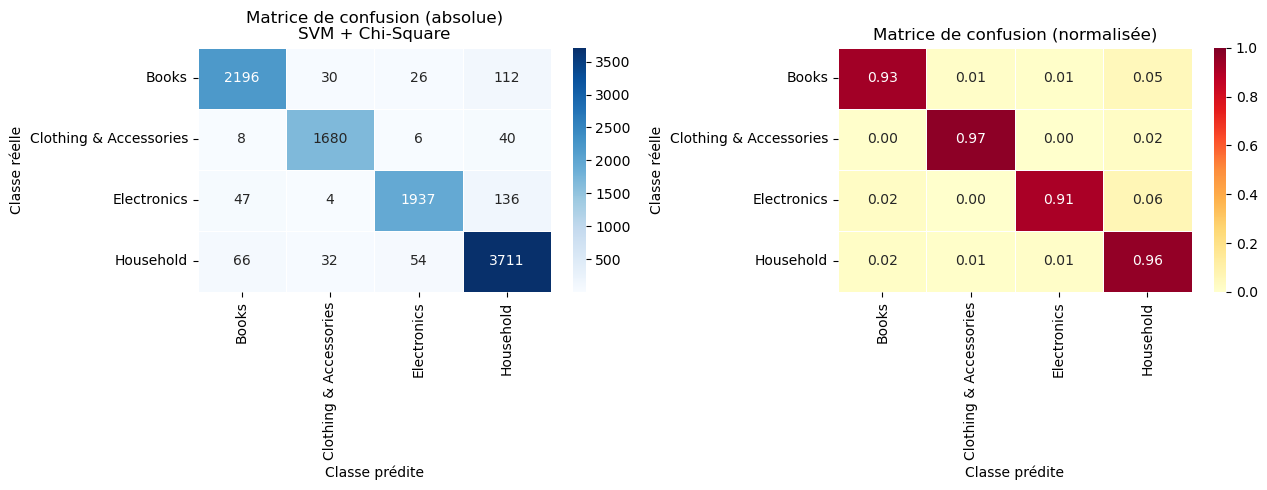

In [18]:
best_clf_name   = best['Classifier']
best_method_key = [k for k, v in METHOD_LABELS.items() if v == best['Method']][0]
yp_best         = predictions[(best_clf_name, best_method_key)]

cm      = confusion_matrix(y_test, yp_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = le.classes_

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='white')
axes[0].set_title(f'Matrice de confusion (absolue)\n{best_clf_name} + {best["Method"]}')
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Classe réelle')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            vmin=0, vmax=1, linewidths=0.5, linecolor='white')
axes[1].set_title('Matrice de confusion (normalisée)')
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Classe réelle')

plt.tight_layout()
plt.show()

In [19]:
print(f'Rapport de classification — {best_clf_name} + {best["Method"]}')
print('=' * 60)
print(classification_report(y_test, yp_best, target_names=le.classes_))

Rapport de classification — SVM + Chi-Square
                        precision    recall  f1-score   support

                 Books       0.95      0.93      0.94      2364
Clothing & Accessories       0.96      0.97      0.97      1734
           Electronics       0.96      0.91      0.93      2124
             Household       0.93      0.96      0.94      3863

              accuracy                           0.94     10085
             macro avg       0.95      0.94      0.95     10085
          weighted avg       0.94      0.94      0.94     10085



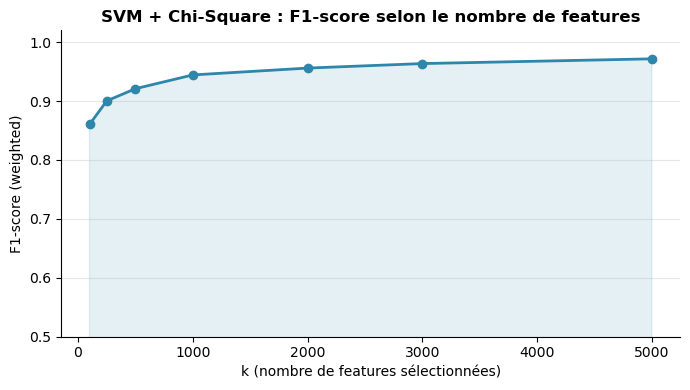

In [20]:
k_values = [100, 250, 500, 1000, 2000, 3000, 5000]
f1_curve = []

for k in k_values:
    k_eff = min(k, X_train_tfidf.shape[1])
    sel   = SelectKBest(chi2, k=k_eff)
    Xtr_k = sel.fit_transform(X_train_tfidf, y_train)
    Xte_k = sel.transform(X_test_tfidf)
    m     = LinearSVC(C=1.0, max_iter=3000, random_state=42)
    m.fit(Xtr_k, y_train)
    f1_curve.append(f1_score(y_test, m.predict(Xte_k), average='weighted'))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values[:len(f1_curve)], f1_curve, marker='o', color='#2E86AB',
        linewidth=2, markersize=6)
ax.fill_between(k_values[:len(f1_curve)], f1_curve, alpha=0.12, color='#2E86AB')
ax.set_title('SVM + Chi-Square : F1-score selon le nombre de features', fontweight='bold')
ax.set_xlabel('k (nombre de features sélectionnées)')
ax.set_ylabel('F1-score (weighted)')
ax.set_ylim(0.5, 1.02)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Conclusion

Cette étude comparative a testé **16 combinaisons** (4 classifieurs × 4 méthodes de sélection de variables) sur le dataset eCommerce.

**Principaux résultats :**

- **SVM, KNN et XGBoost** atteignent des performances très élevées (F1 ≥ 0.94). Le SVM linéaire confirme sa robustesse sur les vecteurs TF-IDF.
- **L'arbre de décision** montre une plus grande sensibilité au choix de la méthode de sélection, performant mieux avec Fisher's Score qu'avec Information Gain sur ce dataset.
- **Information Gain vs Mutual Information :** Bien que proches, l'approche binaire (Information Gain) et l'approche continue (Mutual Information) capturent des signaux légèrement différents, prouvant l'intérêt de tester les deux représentations.
- **Fisher's Score (ANOVA)** s'est avéré être un excellent compromis pour isoler les mots-clés les plus discriminants entre les catégories de produits.
- **Recommandation :** Le couple **SVM + Chi-Square** reste la solution la plus performante et stable pour cette tâche de classification.